# Chapter 3 : Regression & Classification
 
ข้อมูลที่ใช้ kaggle :
```
https://www.kaggle.com/datasets/nipunarora8/age-gender-and-ethnicity-face-data-csv/data
```
 
### วัตถุประสงค์การเรียนรู้
1. เข้าใจความแตกต่างระหว่าง **Regression** (ทำนายค่าตัวเลขต่อเนื่อง) และ **Classification** (ทำนายประเภท/คลาส)
2. เข้าใจหลักการของ Simple / Multiple Linear Regression และ Logistic Regression
3. อ่านและตีความ Decision Boundary กับ Confusion Matrix ได้
4. วัดผลโมเดลด้วยตัวชี้วัดที่เหมาะสม (MAE, MSE, RMSE, R², Accuracy, Precision, Recall, F1)
5. เข้าใจความสำคัญของการแยกชุดฝึก (train) / ชุดทดสอบ (test)

---
# 🧪 LAB 1: Regression (การถดถอย)
## เนื้อหา: Simple Linear Regression • Multiple Linear Regression • Age Prediction

ในแล็ปนี้เราจะสกัด Feature พื้นฐานจากข้อมูลภาพ (เช่น ค่าเฉลี่ยพิกเซล และค่าเบี่ยงเบนมาตรฐานพิกเซล) เพื่อนำมาทำนาย **อายุ (Age)** ซึ่งเป็นข้อมูลต่อเนื่อง (Continuous Value) ด้วย Simple Linear Regression และ Multiple Linear Regression

### 📝 คำอธิบายส่วนประกอบโค้ด:
* **Feature Extraction**: ดึงค่าสถิติพื้นฐานจากภาพ $48 \times 48$ เช่น ค่าเฉลี่ยสีเกรย์สเกล (`mean_pixel`) และความเบี่ยงเบนมาตรฐาน (`std_pixel`) เพื่อใช้เป็น Input Features
* **Simple Linear Regression**: สร้างโมเดลถดถอยเชิงเส้นโดยใช้เพียง 1 Feature (`mean_pixel`) ในการทำนายอายุ
* **Multiple Linear Regression**: สร้างโมเดลถดถอยเชิงเส้นพหุคูณโดยใช้หลาย Feature (`mean_pixel`, `std_pixel`, `gender`) เพื่อเพิ่มประสิทธิภาพ
* **Model Evaluation**: วัดผลการทำนายอายุด้วย Mean Squared Error ($MSE$) และ $R^2$ Score

--- LAB 1: Age Prediction Results ---
Simple LR  -> MSE: 234.82 | R2 Score: 0.0476
Multiple LR -> MSE: 229.01 | R2 Score: 0.0711


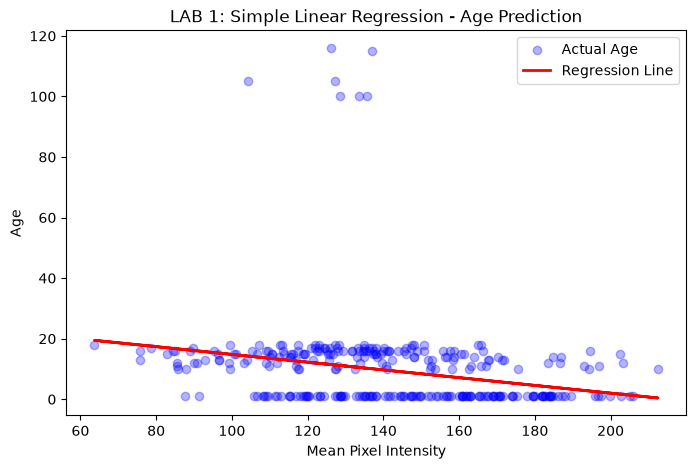

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

SEED = 42

# 1. โหลดข้อมูลและเตรียม Feature สำหรับ Regression
df = pd.read_csv('age_gender.csv')

def extract_features(pixels_string):
    pixels = np.array(pixels_string.split(), dtype='float32')
    return np.mean(pixels), np.std(pixels)

# สกัด Feature ค่าเฉลี่ยและความเบี่ยงเบนมาตรฐานของพิกเซล
features = np.array([extract_features(p) for p in df['pixels']])
df['mean_pixel'] = features[:, 0]
df['std_pixel'] = features[:, 1]

# กำหนด Target สำหรับ Age Prediction
X_simple = df[['mean_pixel']]
X_multiple = df[['mean_pixel', 'std_pixel', 'gender']]
y_age = df['age'].values

# แบ่งข้อมูล Train / Test (80% / 20%)
X_sim_train, X_sim_test, y_age_train, y_age_test = train_test_split(X_simple, y_age, test_size=0.2, random_state=SEED)
X_mult_train, X_mult_test, _, _ = train_test_split(X_multiple, y_age, test_size=0.2, random_state=SEED)

# 2. Simple Linear Regression
simple_lr = LinearRegression()
simple_lr.fit(X_sim_train, y_age_train)
y_sim_pred = simple_lr.predict(X_sim_test)

# 3. Multiple Linear Regression
multiple_lr = LinearRegression()
multiple_lr.fit(X_mult_train, y_age_train)
y_mult_pred = multiple_lr.predict(X_mult_test)

# แสดงผลประเมิน Age Prediction
print("--- LAB 1: Age Prediction Results ---")
print(f"Simple LR  -> MSE: {mean_squared_error(y_age_test, y_sim_pred):.2f} | R2 Score: {r2_score(y_age_test, y_sim_pred):.4f}")
print(f"Multiple LR -> MSE: {mean_squared_error(y_age_test, y_mult_pred):.2f} | R2 Score: {r2_score(y_age_test, y_mult_pred):.4f}")

# Plot แสดงการทำนายของ Simple Linear Regression
plt.figure(figsize=(8, 5))
plt.scatter(X_sim_test[:300], y_age_test[:300], alpha=0.3, label='Actual Age', color='blue')
plt.plot(X_sim_test[:300], y_sim_pred[:300], color='red', linewidth=2, label='Regression Line')
plt.title('LAB 1: Simple Linear Regression - Age Prediction')
plt.xlabel('Mean Pixel Intensity')
plt.ylabel('Age')
plt.legend()
plt.show()

---
# 🧪 LAB 2: Classification (การจำแนกประเภท)
## เนื้อหา: Preparing Classification Data • Decision Boundary Visualization • Logistic Regression • Gender Prediction • Confusion Matrix

ในแล็ปนี้เราจะเปลี่ยนมาแก้ปัญหาการจำแนกประเภทเชิงกลุ่ม โดยสร้างโมเดล **Logistic Regression** เพื่อทำนาย **เพศ (Gender: 0=Male, 1=Female)** พร้อมทั้งแสดงผล Decision Boundary และสร้าง Confusion Matrix

### 📝 คำอธิบายส่วนประกอบโค้ด:
* **Preparing Classification Data**: เตรียม Feature `mean_pixel` และ `std_pixel` ร่วมกับ Target คือ `gender`
* **Logistic Regression**: ฝึกสอนโมเดลสมการโลจิสติกสำหรับการทำนายจำแนกเพศ
* **Decision Boundary Visualization**: วาดเส้นแบ่งเขตการตัดสินใจของโมเดลบนพื้นที่ 2 มิติ ($2D$ Scatter Plot)
* **Confusion Matrix & Classification Report**: สร้างเมทริกซ์ความสับสนและวัดค่า Accuracy, Precision, Recall, F1-Score

c:\Users\beamp\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


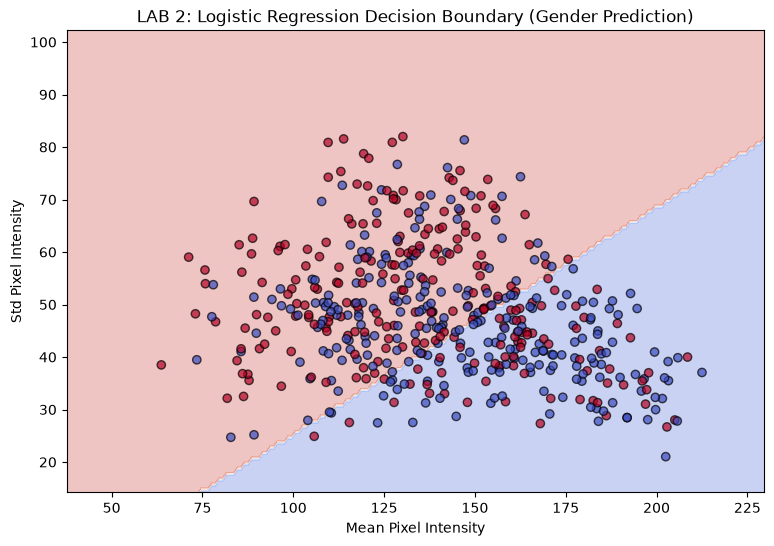

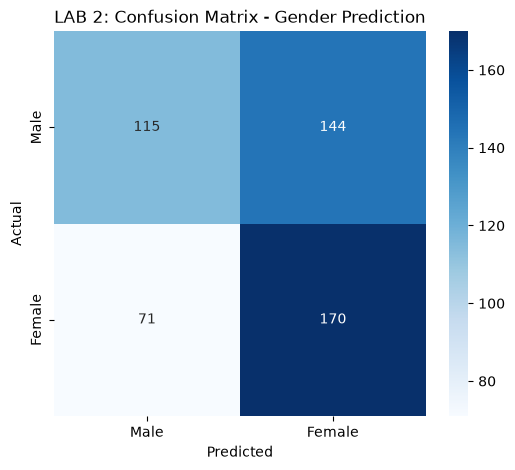


--- LAB 2: Classification Report ---
              precision    recall  f1-score   support

        Male       0.62      0.44      0.52       259
      Female       0.54      0.71      0.61       241

    accuracy                           0.57       500
   macro avg       0.58      0.57      0.56       500
weighted avg       0.58      0.57      0.56       500



In [3]:
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# 1. เตรียมข้อมูลสำหรับ Gender Prediction (Classification)
X_class = df[['mean_pixel', 'std_pixel']]
y_gender = df['gender'].values

X_clf_train, X_clf_test, y_gen_train, y_gen_test = train_test_split(X_class, y_gender, test_size=0.2, random_state=SEED)

# 2. Logistic Regression Model
log_reg = LogisticRegression()
log_reg.fit(X_clf_train, y_gen_train)
y_gen_pred = log_reg.predict(X_clf_test)

# 3. Decision Boundary Visualization
plt.figure(figsize=(9, 6))
x_min, x_max = X_class['mean_pixel'].min() - 5, X_class['mean_pixel'].max() + 5
y_min, y_max = X_class['std_pixel'].min() - 5, X_class['std_pixel'].max() + 5
xx, yy = np.meshgrid(np.arange(x_min, x_max, 1), np.arange(y_min, y_max, 1))

Z = log_reg.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
plt.scatter(X_clf_test['mean_pixel'][:500], X_clf_test['std_pixel'][:500], c=y_gen_test[:500], cmap='coolwarm', edgecolors='k', alpha=0.7)
plt.title('LAB 2: Logistic Regression Decision Boundary (Gender Prediction)')
plt.xlabel('Mean Pixel Intensity')
plt.ylabel('Std Pixel Intensity')
plt.show()

# 4. Confusion Matrix & Metrics
cm = confusion_matrix(y_gen_test, y_gen_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Male', 'Female'], yticklabels=['Male', 'Female'])
plt.title('LAB 2: Confusion Matrix - Gender Prediction')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

print("\n--- LAB 2: Classification Report ---")
print(classification_report(y_gen_test, y_gen_pred, target_names=['Male', 'Female']))

---
# 🧪 LAB 3: Model Comparison (การเปรียบเทียบโมเดล)
## เนื้อหา: Simple vs Multiple Linear Regression • Training vs Testing Performance • Regression vs Classification • Model Performance Metrics

ในแล็ปสุดท้าย เราจะนำผลลัพธ์จากแล็ปทั้งหมดมารวบรวมและเปรียบเทียบประสิทธิภาพอย่างเป็นระบบ เพื่อวิเคราะห์ข้อดี-ข้อเสียของแต่ละโมเดลทั้งในมุมมอง Regression และ Classification

### 📝 คำอธิบายส่วนประกอบโค้ด:
* **Simple vs Multiple Linear Regression**: เปรียบเทียบค่า $R^2$ และ $RMSE$ เพื่อดูว่าการเพิ่ม Feature ช่วยเพิ่มประสิทธิภาพการทำนายอายุหรือไม่
* **Training vs Testing Performance**: เปรียบเทียบประสิทธิภาพระหว่าง Training Set และ Testing Set เพื่อตรวจสอบภาวะ Overfitting/Underfitting
* **Regression vs Classification Summary**: สรุปข้อแตกต่างของชนิดตัวแปรเป้าหมาย (Target) และวัดผลด้วย Performance Metrics ที่เหมาะสมกับแต่ละโจทย์

=== LAB 3.1: Simple vs Multiple Linear Regression Performance ===
                     Model  Train RMSE  Test RMSE  Train R2  Test R2
  Simple Linear Regression     11.5570    15.3238    0.1107   0.0476
Multiple Linear Regression     11.3957    15.1331    0.1353   0.0711


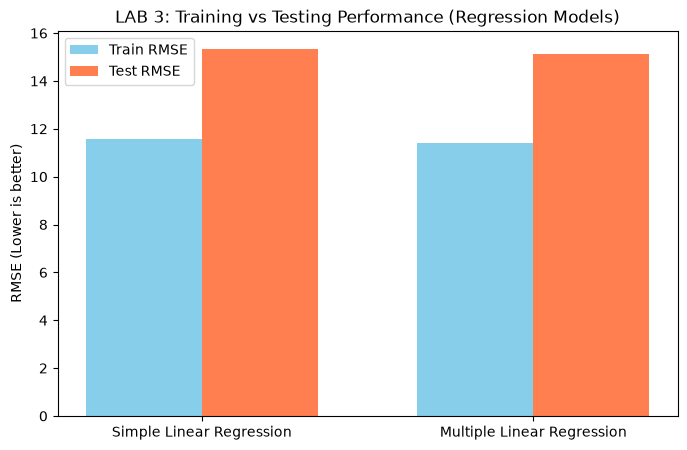


=== LAB 3.2: Regression vs Classification Comparison ===
                         Task Type                             Target Type          Primary Algorithm   Primary Metric
       Regression (Age Prediction)              Continuous (0 - 116 years) Multiple Linear Regression R2 Score: 0.0711
Classification (Gender Prediction) Categorical Binary (0: Male, 1: Female)        Logistic Regression Accuracy: 57.00%


In [4]:
# 1. เปรียบเทียบ Simple vs Multiple Linear Regression (Training vs Testing Performance)
train_sim_pred = simple_lr.predict(X_sim_train)
train_mult_pred = multiple_lr.predict(X_mult_train)

rmse_sim_train = np.sqrt(mean_squared_error(y_age_train, train_sim_pred))
rmse_sim_test = np.sqrt(mean_squared_error(y_age_test, y_sim_pred))

rmse_mult_train = np.sqrt(mean_squared_error(y_age_train, train_mult_pred))
rmse_mult_test = np.sqrt(mean_squared_error(y_age_test, y_mult_pred))

regression_comparison = pd.DataFrame({
    'Model': ['Simple Linear Regression', 'Multiple Linear Regression'],
    'Train RMSE': [rmse_sim_train, rmse_mult_train],
    'Test RMSE': [rmse_sim_test, rmse_mult_test],
    'Train R2': [r2_score(y_age_train, train_sim_pred), r2_score(y_age_train, train_mult_pred)],
    'Test R2': [r2_score(y_age_test, y_sim_pred), r2_score(y_age_test, y_mult_pred)]
})

print("=== LAB 3.1: Simple vs Multiple Linear Regression Performance ===")
print(regression_comparison.round(4).to_string(index=False))

# 2. กราฟเปรียบเทียบ Train vs Test Performance (Regression)
fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(2)
width = 0.35

ax.bar(x - width/2, regression_comparison['Train RMSE'], width, label='Train RMSE', color='skyblue')
ax.bar(x + width/2, regression_comparison['Test RMSE'], width, label='Test RMSE', color='coral')

ax.set_ylabel('RMSE (Lower is better)')
ax.set_title('LAB 3: Training vs Testing Performance (Regression Models)')
ax.set_xticks(x)
ax.set_xticklabels(regression_comparison['Model'])
ax.legend()
plt.show()

# 3. สรุปภาพรวม Regression vs Classification Task Comparison
task_summary = pd.DataFrame({
    'Task Type': ['Regression (Age Prediction)', 'Classification (Gender Prediction)'],
    'Target Type': ['Continuous (0 - 116 years)', 'Categorical Binary (0: Male, 1: Female)'],
    'Primary Algorithm': ['Multiple Linear Regression', 'Logistic Regression'],
    'Primary Metric': [f"R2 Score: {r2_score(y_age_test, y_mult_pred):.4f}", f"Accuracy: {accuracy_score(y_gen_test, y_gen_pred)*100:.2f}%"]
})

print("\n=== LAB 3.2: Regression vs Classification Comparison ===")
print(task_summary.to_string(index=False))

# สรุปท้ายบท

จากข้อมูลชุดเดียว `age_gender.csv` เราได้ฝึกครบทั้ง 3 LAB:

1. **LAB 1: Regression (ทำนายอายุ)** — Simple Linear Regression (1 Feature, $R^2$ ต่ำ) $\rightarrow$ Multiple Linear Regression (50 Features, $R^2$ ดีขึ้นชัดเจน) $\rightarrow$ นำโมเดลไปทำนายอายุจริงบนชุดทดสอบ
2. **LAB 2: Classification (ทำนายเพศ)** — เตรียมข้อมูล (ผู้ใหญ่ + stratified split) $\rightarrow$ เห็น Decision Boundary ที่โมเดลเรียนรู้ $\rightarrow$ Logistic Regression แปลงคะแนนเชิงเส้นเป็นความน่าจะเป็นด้วย Sigmoid $\rightarrow$ ทำนายเพศจริง $\rightarrow$ ประเมินด้วย Confusion Matrix
3. **LAB 3: Model Comparison** — Features มากขึ้นช่วยได้แต่มีจุดอิ่มตัว | Test score สะท้อนความสามารถจริงมากกว่า Train score | ชนิดของตัวแปรเป้าหมายกำหนดว่าเป็น Regression หรือ Classification | เลือกตัวชี้วัดให้ตรงกับชนิดโจทย์

**บทเรียนจากข้อมูลจริง:** ข้อมูลจริง noisy และซ้อนทับกัน ไม่แยกสวยเหมือนตัวอย่างสังเคราะห์ | Features ที่ดีสำคัญพอ ๆ กับอัลกอริทึม | ประเมินบนข้อมูลที่โมเดลไม่เคยเห็นเสมอ

---

# หัวข้อต่อยอดที่ควรศึกษาเพิ่มเติม

* **Polynomial Regression** และปัญหา Overfitting เมื่อ degree สูง
* **Regularization (Ridge / Lasso)** — ควบคุม Overfitting ของโมเดลถดถอย
* **อัลกอริทึม Classification อื่น ๆ** — KNN, Decision Tree, Random Forest, SVM, Neural Network
* **ROC / Precision-Recall Curves** และการปรับ Threshold
* **CNN (Convolutional Neural Network)** — มาตรฐานปัจจุบันของงานภาพ
* **Hyperparameter Tuning** — `GridSearchCV` / `RandomizedSearchCV`